<a href="https://colab.research.google.com/github/cailuj/TCC/blob/main/ajustes_explicabilidade_resnet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, applications
from sklearn.model_selection import GroupShuffleSplit
from google.colab import drive

drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/MINI-DDSM/'
EXCEL_PATH = os.path.join(BASE_PATH, 'DataWMask.xlsx')
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
CHANNELS = 3
SEED = 42

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_excel(EXCEL_PATH)

df['fullPath'] = df['fullPath'].str.replace('\\', '/', regex=False)
df['Tumour_Contour'] = df['Tumour_Contour'].str.replace('\\', '/', regex=False)

def extract_patient_id(path):
    parts = path.split('/')
    return parts[1] if len(parts) > 1 else 'unknown'

df['patient_id'] = df['fullPath'].apply(extract_patient_id)

class_map = {'Normal': 0, 'Benign': 1, 'Cancer': 2}
df['label'] = df['Status'].map(class_map)

gss_test = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_val_idx, test_idx = next(gss_test.split(df, df['label'], groups=df['patient_id']))

train_val_df = df.iloc[train_val_idx]
test_df = df.iloc[test_idx]

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, val_idx = next(gss_val.split(train_val_df, train_val_df['label'], groups=train_val_df['patient_id']))

train_df = train_val_df.iloc[train_idx]
val_df = train_val_df.iloc[val_idx]

print(f'Treino: {len(train_df)} | Val: {len(val_df)} | Teste: {len(test_df)}')

Treino: 4968 | Val: 1236 | Teste: 1604


In [ ]:
def load_and_preprocess(path, label):
    full_path = tf.strings.join([BASE_PATH, path])
    img = tf.io.read_file(full_path)
    img = tf.image.decode_jpeg(img, channels=CHANNELS)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def create_ds(dataframe, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((dataframe['fullPath'].values, dataframe['label'].values))
    if shuffle:
        ds = ds.shuffle(len(dataframe))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = create_ds(train_df)
val_ds = create_ds(val_df, shuffle=False)
test_ds = create_ds(test_df, shuffle=False)

In [ ]:
base_model = applications.ResNet50(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
base_model.trainable = True

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

checkpoint = callbacks.ModelCheckpoint('best_model.keras', save_best_only=True, monitor='val_loss')

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[checkpoint]
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 459s 3s/step - accuracy: 0.6413 - loss: 0.7309 - val_accuracy: 0.3819 - val_loss: 1.1317
Epoch 2/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 19s 122ms/step - accuracy: 0.7703 - loss: 0.5188 - val_accuracy: 0.2848 - val_loss: 2.0878
Epoch 3/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 20s 127ms/step - accuracy: 0.8498 - loss: 0.3680 - val_accuracy: 0.3495 - val_loss: 1.4296
Epoch 4/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 19s 120ms/step - accuracy: 0.8996 - loss: 0.2573 - val_accuracy: 0.3892 - val_loss: 1.3803
Epoch 5/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 19s 121ms/step - accuracy: 0.9231 - loss: 0.2047 - val_accuracy: 0.4693 - val_loss: 1.1896
Epoch 6/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 21s 136ms/step - accuracy: 0.9507 - loss: 0.1282 - val_accuracy: 0.5858 - val_loss: 1.0424
Epoch 7/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 21s 132ms/step - accuracy: 0.9634 - loss: 0.1039 - val_accuracy: 0.6545 - val_loss: 1.0061
Epoch 8/50
156/156 ━━━━━━━━━━━━━━━

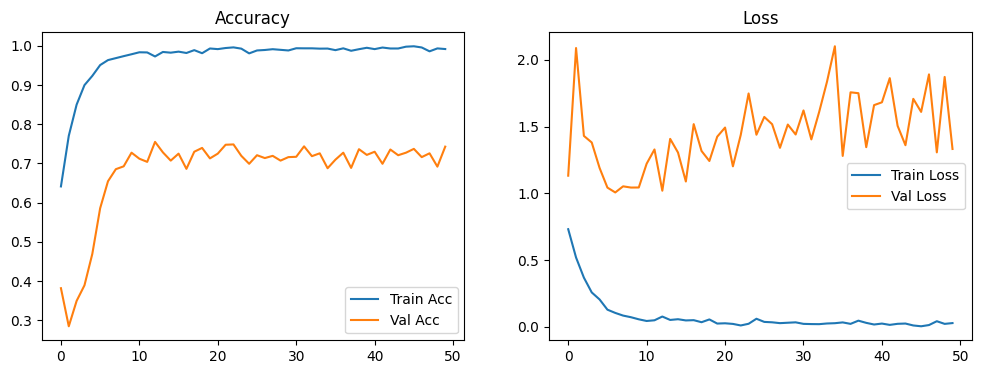

51/51 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.7506 - loss: 1.2382

Acurácia no Teste (Holdout): 0.7506

Calculando métricas detalhadas...
51/51 ━━━━━━━━━━━━━━━━━━━━ 13s 169ms/step

Relatório de Classificação:
              precision    recall  f1-score   support

      Normal       0.89      0.88      0.88       588
      Benign       0.71      0.60      0.65       516
      Cancer       0.64      0.75      0.69       500

    accuracy                           0.75      1604
   macro avg       0.75      0.74      0.74      1604
weighted avg       0.75      0.75      0.75      1604



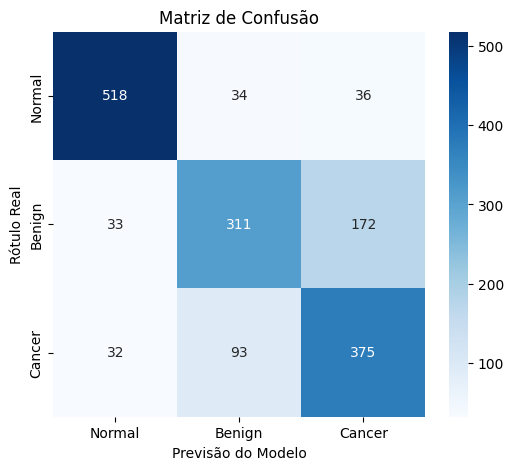

In [ ]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

test_loss, test_acc = model.evaluate(test_ds)
print(f'\nAcurácia no Teste (Holdout): {test_acc:.4f}')

print("\nCalculando métricas detalhadas...")
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nRelatório de Classificação:")
target_names = ['Normal', 'Benign', 'Cancer']
print(classification_report(y_true, y_pred, target_names=target_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Matriz de Confusão')
plt.ylabel('Rótulo Real')
plt.xlabel('Previsão do Modelo')
plt.show()

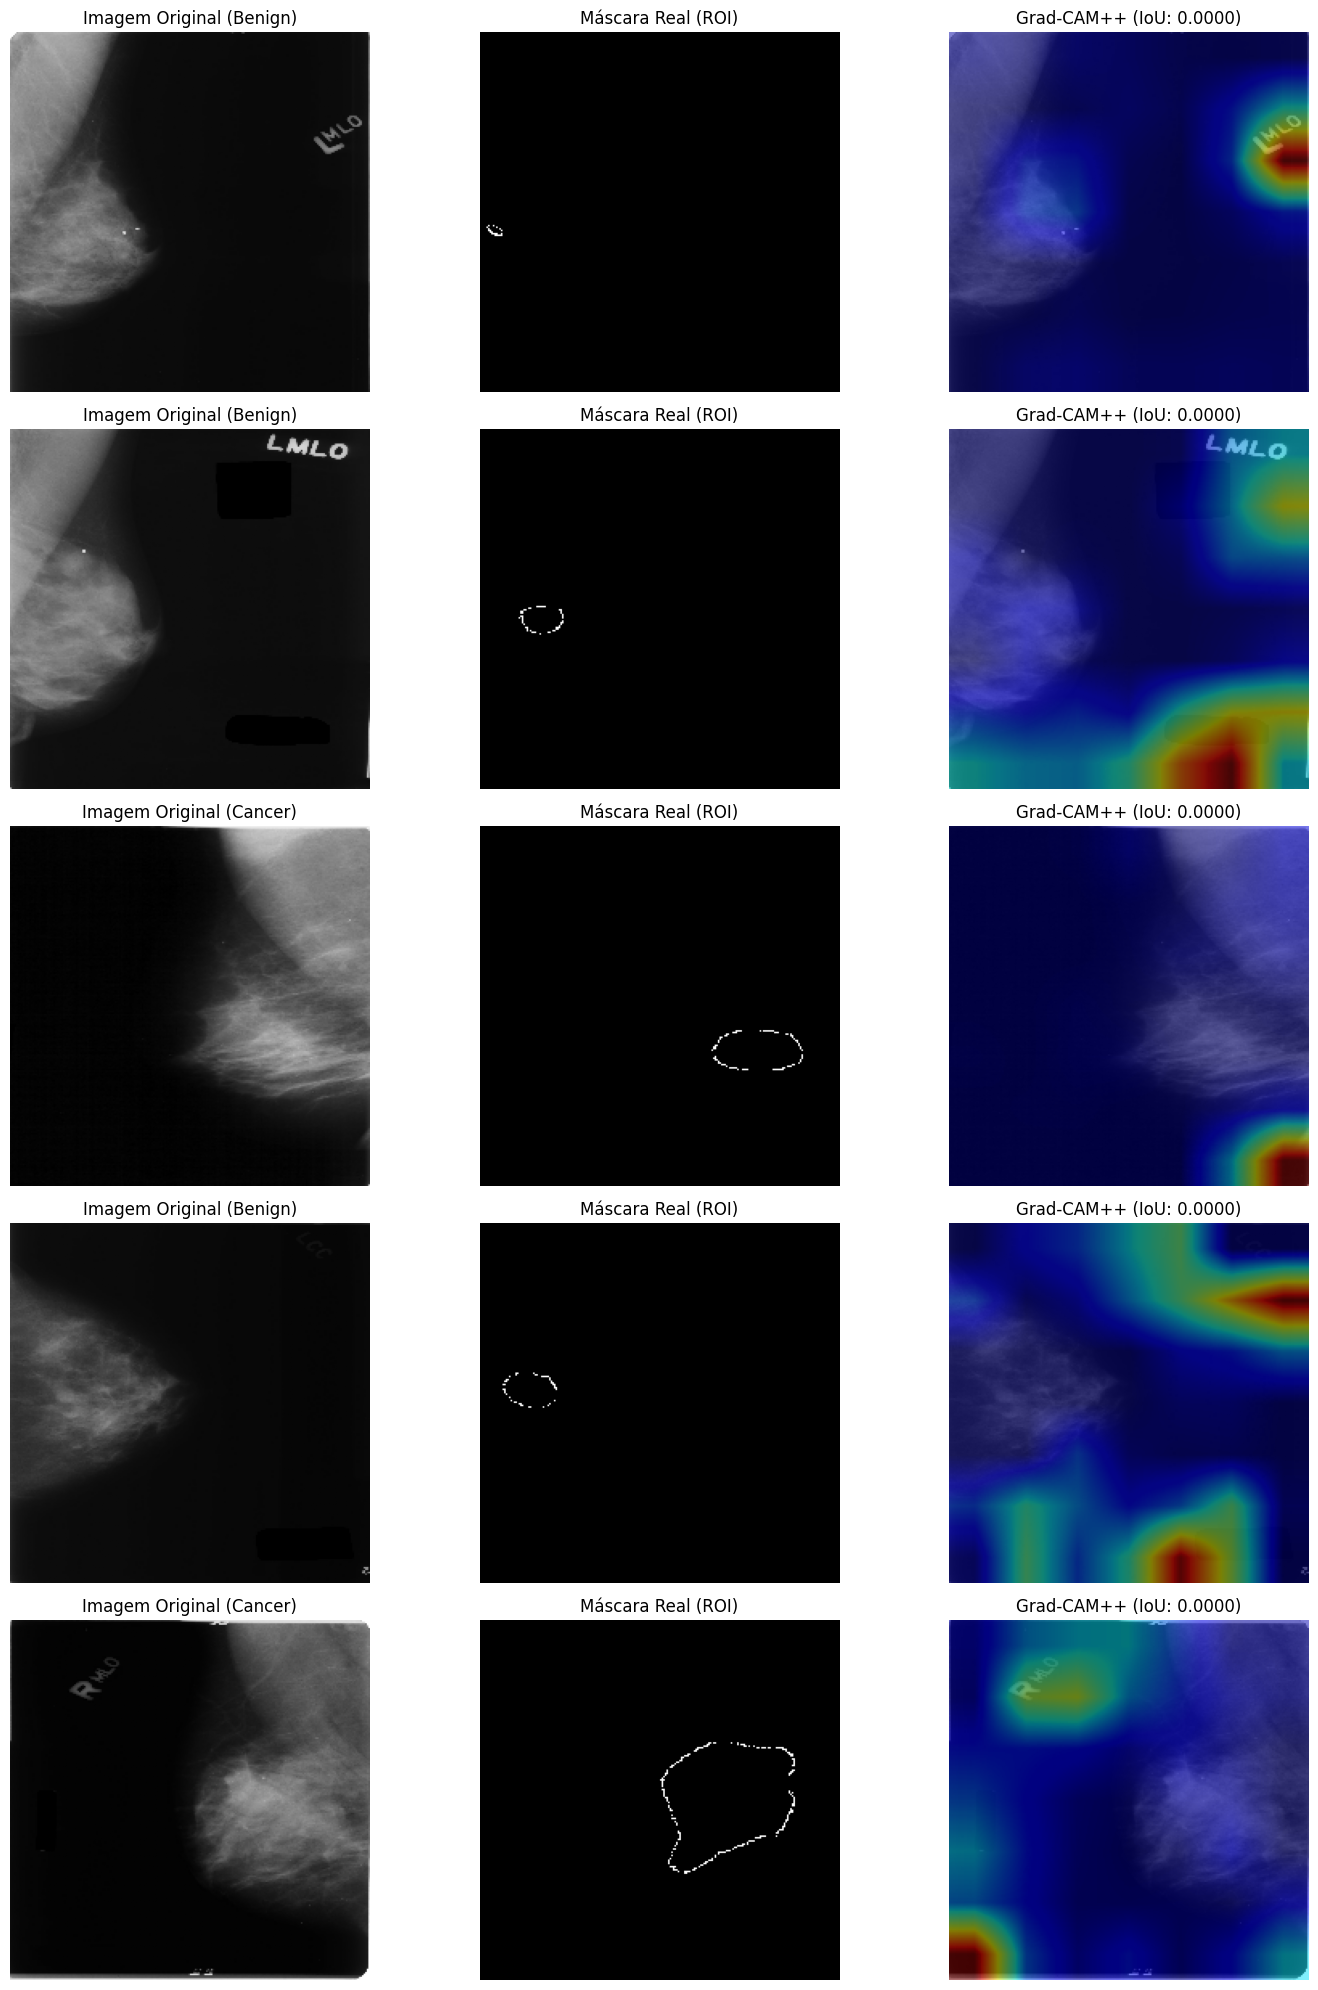

In [ ]:
import cv2
import numpy as np

def get_gradcam_plus_plus(model, img_array, last_conv_layer_name):
    base_model = model.get_layer('resnet50')
    last_conv_layer = base_model.get_layer(last_conv_layer_name)

    res_output = last_conv_layer.output

    x = model.get_layer('global_average_pooling2d')(base_model.output)
    for layer in model.layers[2:]:
        x = layer(x)

    grad_model = tf.keras.models.Model([base_model.input], [res_output, x])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)

    weights = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.reduce_sum(tf.multiply(weights, conv_outputs), axis=-1)

    heatmap = np.maximum(heatmap, 0) / (np.max(heatmap) + 1e-10)
    return heatmap[0]

def calculate_iou(y_true, y_pred):
    intersection = np.logical_and(y_true, y_pred)
    union = np.logical_or(y_true, y_pred)
    if np.sum(union) == 0: return 0
    return np.sum(intersection) / np.sum(union)

test_with_masks = test_df[(test_df['Status'] != 'Normal') & (test_df['Tumour_Contour'] != '-')]

if len(test_with_masks) >= 5:
    sample_rows = test_with_masks.sample(5, random_state=SEED)

    fig, axes = plt.subplots(5, 3, figsize=(15, 20))

    for i, (_, row) in enumerate(sample_rows.iterrows()):
        img_path = os.path.join(BASE_PATH, row['fullPath'])
        mask_path = os.path.join(BASE_PATH, row['Tumour_Contour'])

        img_raw = tf.io.read_file(img_path)
        img_decoded = tf.image.decode_jpeg(img_raw, channels=3)
        img_resized = tf.image.resize(img_decoded, IMG_SIZE)
        img_normalized = tf.cast(img_resized, tf.float32) / 255.0
        img_batch = tf.expand_dims(img_normalized, 0)

        try:
            heatmap = get_gradcam_plus_plus(model, img_batch, 'conv5_block3_out')

            mask_img = cv2.imread(mask_path, 0)
            if mask_img is not None:
                mask = cv2.resize(mask_img, IMG_SIZE) > 0
                heatmap_resized = cv2.resize(heatmap, IMG_SIZE)
                heatmap_bin = heatmap_resized > 0.5
                iou_score = calculate_iou(mask, heatmap_bin)

                axes[i, 0].imshow(img_normalized)
                axes[i, 0].set_title(f'Imagem Original ({row["Status"]})')
                axes[i, 0].axis('off')

                axes[i, 1].imshow(mask, cmap='gray')
                axes[i, 1].set_title('Máscara Real (ROI)')
                axes[i, 1].axis('off')

                axes[i, 2].imshow(img_normalized)
                axes[i, 2].imshow(heatmap_resized, alpha=0.5, cmap='jet')
                axes[i, 2].set_title(f'Grad-CAM++ (IoU: {iou_score:.4f})')
                axes[i, 2].axis('off')
            else:
                print(f'Erro ao carregar o arquivo de máscara para a amostra {i+1}.')
        except Exception as e:
            print(f'Erro na execução do Grad-CAM++ para a amostra {i+1}: {e}')

    plt.tight_layout()
    plt.show()
else:
    print('Nenhuma amostra com máscara encontrada no conjunto de teste.')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

sample_df = test_df[(test_df['Status'] != 'Normal') & (test_df['Tumour_Contour'] != '-')].sample(5, random_state=SEED)

sample_images = []
sample_labels = []
sample_masks = []

for _, row in sample_df.iterrows():
    img_path = os.path.join(BASE_PATH, row['fullPath'])
    img_raw = tf.io.read_file(img_path)
    img_decoded = tf.image.decode_jpeg(img_raw, channels=3)
    img_resized = tf.image.resize(img_decoded, IMG_SIZE)
    img_normalized = tf.cast(img_resized, tf.float32) / 255.0
    sample_images.append(img_normalized.numpy())
    sample_labels.append(row['label'])

    mask_path = os.path.join(BASE_PATH, row['Tumour_Contour'])
    mask_raw = cv2.imread(mask_path, 0)
    if mask_raw is not None:
        mask_resized = cv2.resize(mask_raw, IMG_SIZE)
    else:
        mask_resized = np.zeros(IMG_SIZE)
    sample_masks.append(mask_resized)

sample_images = np.array(sample_images)
sample_labels = np.array(sample_labels)
sample_masks = np.array(sample_masks)
print(f'Selecionadas {len(sample_images)} imagens com máscaras para explicação.')

Selecionadas 5 imagens com máscaras para explicação.


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from scipy.stats import pearsonr
from scipy.ndimage import center_of_mass

OUTPUT_DIR = './xai_diagnostic_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
TARGET_LAYER_NAME = 'conv5_block3_out'

def apply_transformations(img):
    transforms = {'Original': img}
    transforms['Flip_H'] = cv2.flip(img, 1)
    M = cv2.getRotationMatrix2D((IMG_SIZE[0]//2, IMG_SIZE[1]//2), 15, 1.0)
    transforms['Rot_15'] = cv2.warpAffine(img, M, IMG_SIZE)
    transforms['Brightness'] = np.clip(img * 1.2, 0.0, 1.0)
    noise = np.random.normal(0, 0.05, img.shape)
    transforms['Noise'] = np.clip(img + noise, 0.0, 1.0)
    return transforms

def calc_metrics(hm_orig, hm_trans, pred_orig, pred_trans):
    same_pred = int(pred_orig == pred_trans)

    corr, _ = pearsonr(hm_orig.flatten(), hm_trans.flatten())
    corr = 0 if np.isnan(corr) else corr

    bin_orig = hm_orig > 0.5
    bin_trans = hm_trans > 0.5
    intersection = np.logical_and(bin_orig, bin_trans).sum()
    union = np.logical_or(bin_orig, bin_trans).sum()
    iou = intersection / union if union > 0 else 0.0

    com_orig = center_of_mass(hm_orig)
    com_trans = center_of_mass(hm_trans)
    if np.isnan(com_orig).any() or np.isnan(com_trans).any():
        dist = np.nan
    else:
        dist = np.linalg.norm(np.array(com_orig) - np.array(com_trans))

    return same_pred, corr, iou, dist

results = []

for i, img in enumerate(sample_images):
    img_transforms = apply_transformations(img)

    orig_img_batch = np.expand_dims(img_transforms['Original'], 0)
    pred_orig = np.argmax(model.predict(orig_img_batch, verbose=0))
    hm_orig = get_gradcam_plus_plus(model, orig_img_batch, TARGET_LAYER_NAME)

    fig, axes = plt.subplots(1, len(img_transforms), figsize=(20, 4))
    fig.suptitle(f'Imagem {i+1} - Real: {sample_labels[i]} | Pred Original: {pred_orig}', fontsize=16)

    for j, (t_name, t_img) in enumerate(img_transforms.items()):
        t_img_batch = np.expand_dims(t_img, 0)
        pred_trans = np.argmax(model.predict(t_img_batch, verbose=0))
        hm_trans = get_gradcam_plus_plus(model, t_img_batch, TARGET_LAYER_NAME)

        if t_name == 'Original':
            same_pred, corr, iou, dist = 1, 1.0, 1.0, 0.0
        else:
            same_pred, corr, iou, dist = calc_metrics(hm_orig, hm_trans, pred_orig, pred_trans)

        results.append({
            'image_idx': i,
            'transform': t_name,
            'same_prediction_as_original': same_pred,
            'heatmap_corr_vs_original': corr,
            'heatmap_iou_vs_original': iou,
            'heatmap_center_distance_vs_original': dist
        })

        hm_resized = cv2.resize(hm_trans, IMG_SIZE)
        axes[j].imshow(t_img)
        axes[j].imshow(hm_resized, cmap='jet', alpha=0.5)
        axes[j].set_title(f'{t_name}\nPred: {pred_trans}\nIoU: {iou:.2f}')
        axes[j].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'img_{i}_panel.png'))
    plt.close(fig)

df_metrics = pd.DataFrame(results)
df_metrics.to_csv(os.path.join(OUTPUT_DIR, 'diagnostic_metrics.csv'), index=False)

df_summary = df_metrics.groupby('transform').mean().drop(columns=['image_idx'])
df_summary.to_csv(os.path.join(OUTPUT_DIR, 'diagnostic_summary.csv'))

print("Diagnóstico XAI concluído!")
display(df_summary)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


Diagnóstico XAI concluído!


,same_prediction_as_original,heatmap_corr_vs_original,heatmap_iou_vs_original,heatmap_center_distance_vs_original
transform,,,,
Brightness,1.0,0.977164,0.866667,0.247886
Flip_H,1.0,0.058718,0.030769,2.191668
Noise,0.0,0.036123,0.031515,1.446438
Original,1.0,1.000000,1.000000,0.000000
Rot_15,0.4,0.143035,0.062222,1.175244


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 13.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


  0%|          | 0/500 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━

  0%|          | 0/500 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━

  0%|          | 0/500 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━

  0%|          | 0/500 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━

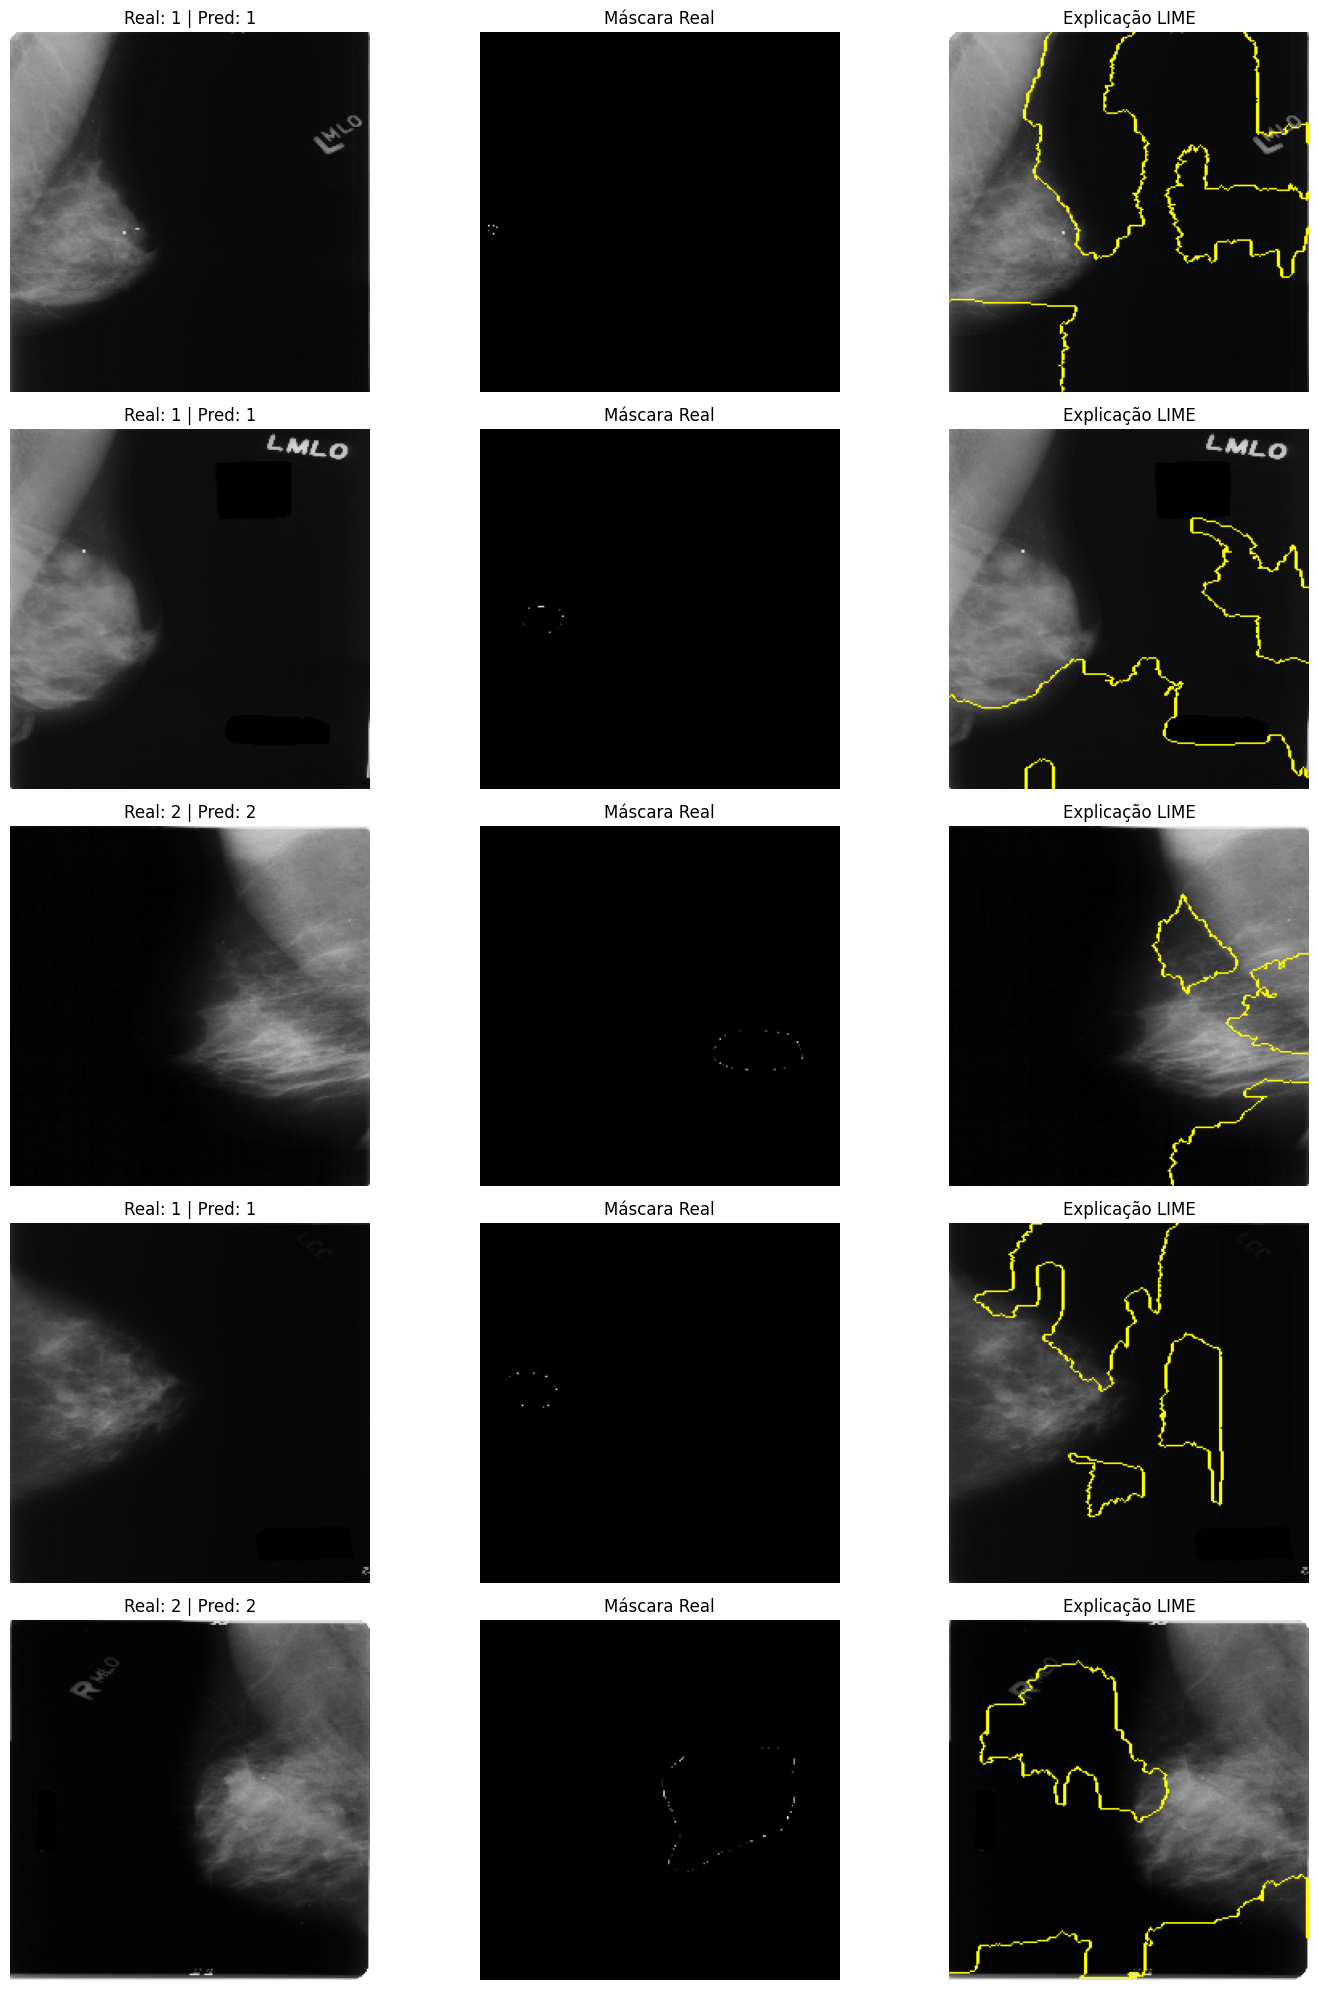

In [ ]:
!pip install lime -q

from lime import lime_image
from skimage.segmentation import mark_boundaries

explainer = lime_image.LimeImageExplainer()

fig, axes = plt.subplots(5, 3, figsize=(15, 20))
for i in range(5):
    img = sample_images[i]
    label = sample_labels[i]
    mask_img = sample_masks[i]

    explanation = explainer.explain_instance(
        img.astype('double'),
        model.predict,
        top_labels=3,
        hide_color=0,
        num_samples=500
    )

    preds = model.predict(np.expand_dims(img, axis=0))
    pred_class = np.argmax(preds)

    temp, mask = explanation.get_image_and_mask(
        pred_class,
        positive_only=True,
        num_features=5,
        hide_rest=False
    )

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f'Real: {label} | Pred: {pred_class}')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(mask_img, cmap='gray')
    axes[i, 1].set_title('Máscara Real')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(mark_boundaries(temp, mask))
    axes[i, 2].set_title('Explicação LIME')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()


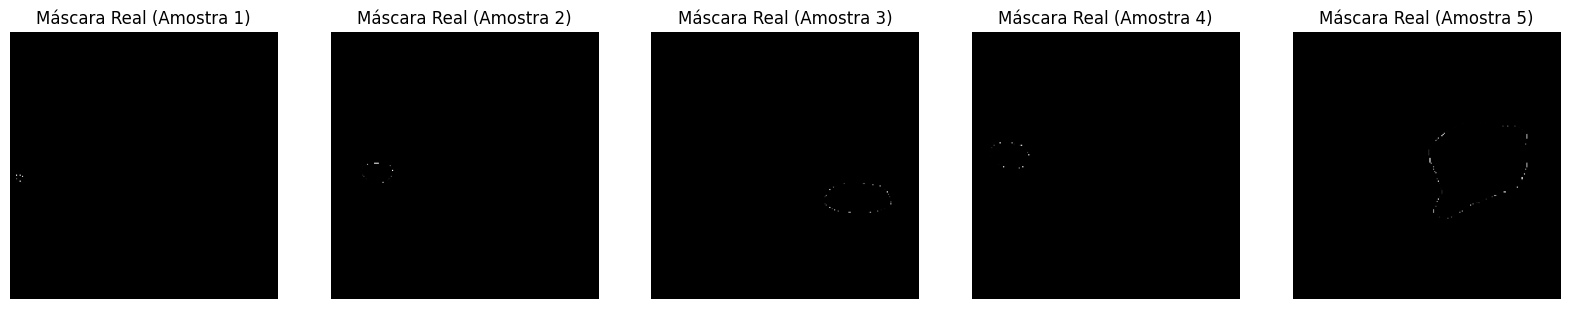

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_175
Received: inputs=['Tensor(shape=(5, 224, 224, 3))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_175
Received: inputs=['Tensor(shape=(50, 224, 224, 3))']
  warnings.warn(msg)


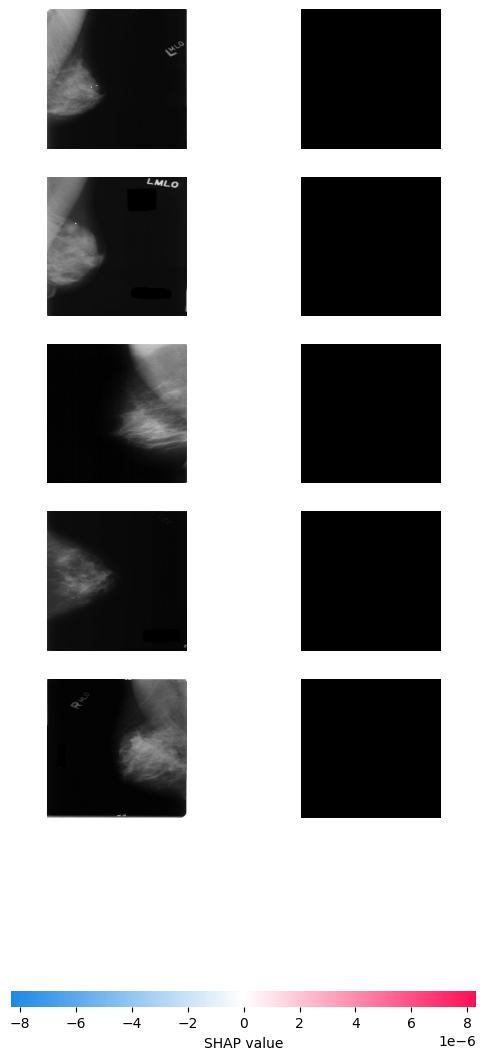

In [ ]:
import shap
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i in range(5):
    axes[i].imshow(sample_masks[i], cmap='gray')
    axes[i].set_title(f'Máscara Real (Amostra {i+1})')
    axes[i].axis('off')
plt.show()

explainer_shap = shap.GradientExplainer(model, sample_images)

shap_values = explainer_shap.shap_values(sample_images)

shap.image_plot(shap_values, sample_images)